# 04 – Feature Vektor Analízis

Betölti a 56 dimenziós `features_v14.npz` feature vektort és elvégzi:
- Leíró statisztikák és feature csoport vizsgálat
- PCA dimenziócsökkentés és scatter plot
- t-SNE dimenziócsökkentés és scatter plot
- Group ablation: csoportonkénti varianciaelemzés

In [ ]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.config import CFG, PATHS
from src.features import load_features, feature_names, GROUP_B_SIZE, GROUP_D_SIZE, GROUP_F_SIZE, GROUP_G_SIZE, GROUP_H_SIZE
from src.viz import plot_scatter_2d, class_color_mpl

OUTPUT_DIR = PATHS['output_dir'] / '04_feature_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Setup kész.')

Setup kész.


## 1. Adatok betöltése

In [ ]:
data = load_features()
X = data['X']          # (297, 56)
y = data['y']          # (297,) integer labels
classes = data['classes']
splits = np.array(data['splits'])
ok_mask = data['ok_mask']
fn = feature_names()

# Train+val részen dolgozunk (test védelem)
trainval_mask = splits != 'test'
X_tv = X[trainval_mask]
y_tv = y[trainval_mask]

print(f'Összes minta: {len(X)}  |  Train+Val: {len(X_tv)}  |  Osztályok: {classes}')
print(f'Pipeline ok: {ok_mask.sum()}/{len(ok_mask)}  ({ok_mask.mean()*100:.1f}%)')
print(f'Feature dim: {X.shape[1]}')

Összes minta: 297  |  Train+Val: 252  |  Osztályok: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('No hand')]
Pipeline ok: 248/297  (83.5%)
Feature dim: 56


## 2. Leíró statisztikák

In [ ]:
# Feature csoport határok
groups = {
    'B – Wrist-norm landmarks (42d)': slice(0, 42),
    'D – Detection flags (2d)':        slice(42, 44),
    'F – Neck angle cos/sin (2d)':      slice(44, 46),
    'G – Fret index per finger (5d)':   slice(46, 51),
    'H – String norm per finger (5d)':  slice(51, 56),
}

print('Feature csoport statisztikák (train+val, absz. átlag és std):')
print(f'{"Csoport":<40} {"Átlag abs":>10}  {"Std":>8}')
print('-' * 62)
for g_name, g_sl in groups.items():
    subset = X_tv[:, g_sl]
    print(f'{g_name:<40} {np.abs(subset).mean():>10.4f}  {subset.std():>8.4f}')

Feature csoport statisztikák (train+val, absz. átlag és std):
Csoport                                   Átlag abs       Std
--------------------------------------------------------------
B – Wrist-norm landmarks (42d)               0.8252    0.9076
D – Detection flags (2d)                     0.8373    0.3691
F – Neck angle cos/sin (2d)                  0.5063    0.4009
G – Fret index per finger (5d)               0.0694    0.1022
H – String norm per finger (5d)              0.3212    0.3738


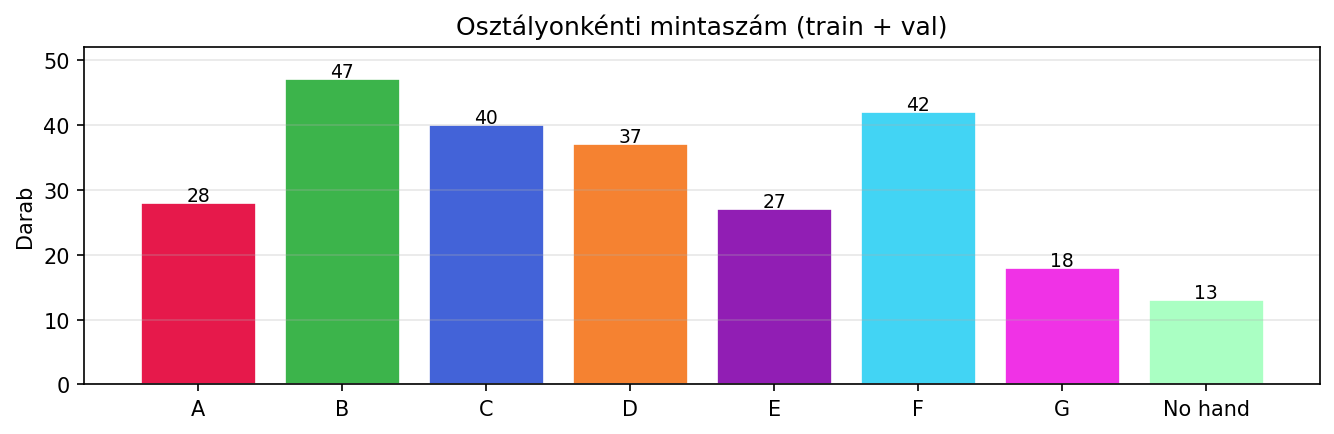

In [ ]:
# Osztályonkénti mintaszám
fig, ax = plt.subplots(figsize=(9, 3))
cls_counts = {c: (y_tv == i).sum() for i, c in enumerate(classes)}
bars = ax.bar(cls_counts.keys(), cls_counts.values(),
               color=[class_color_mpl(i) for i in range(len(classes))],
               edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, cls_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
            ha='center', fontsize=9)
ax.set_title('Osztályonkénti mintaszám (train + val)', fontsize=12)
ax.set_ylabel('Darab')
ax.set_ylim(0, max(cls_counts.values()) + 5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=130)
plt.show()

## 3. Korreláció hőtérkép – Group B feature-ök

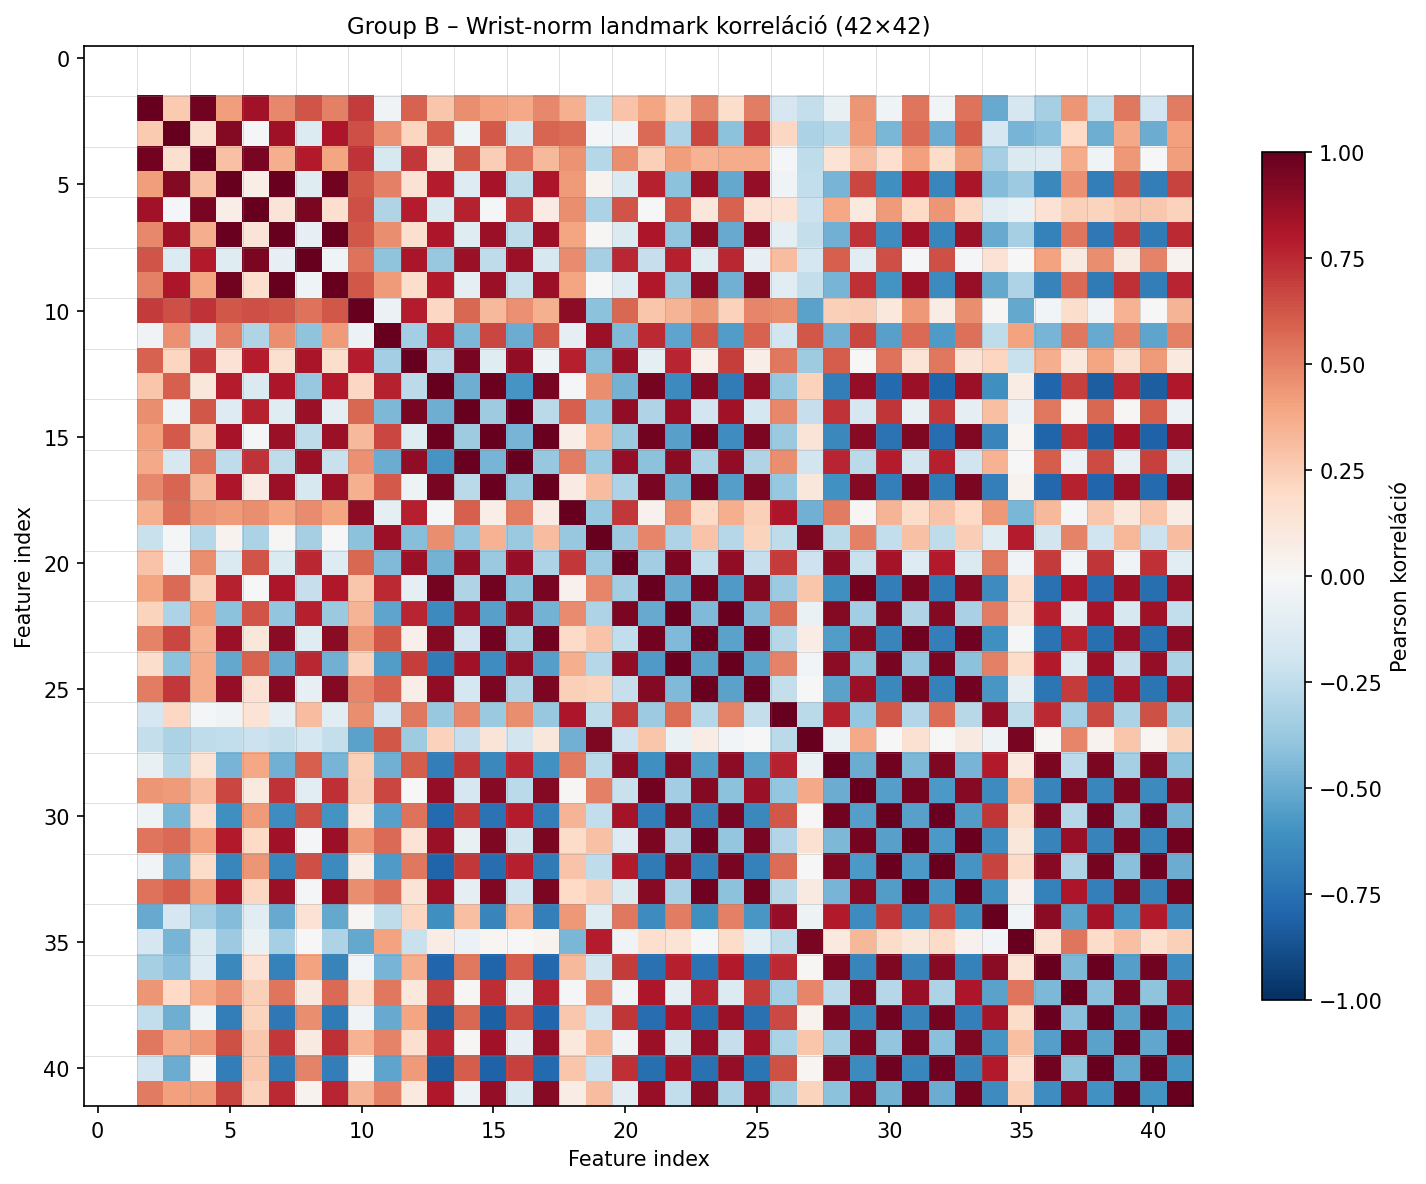

In [ ]:
# Group B (42 dim) korrelációs mátrix
X_B = X_tv[:, :42]
corr = np.corrcoef(X_B.T)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson korreláció')
# Landmark-csoportok elválasztása (x, y párok)
for i in range(0, 42, 2):
    ax.axhline(i - 0.5, color='gray', lw=0.3, alpha=0.4)
    ax.axvline(i - 0.5, color='gray', lw=0.3, alpha=0.4)
ax.set_title('Group B – Wrist-norm landmark korreláció (42×42)', fontsize=11)
ax.set_xlabel('Feature index')
ax.set_ylabel('Feature index')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'correlation_group_B.png', dpi=130)
plt.show()

## 4. PCA – 2D és variancia-magyarázat

PC-k száma 90% variancia eléréséhez: 6
PC-k száma 95% variancia eléréséhez: 9


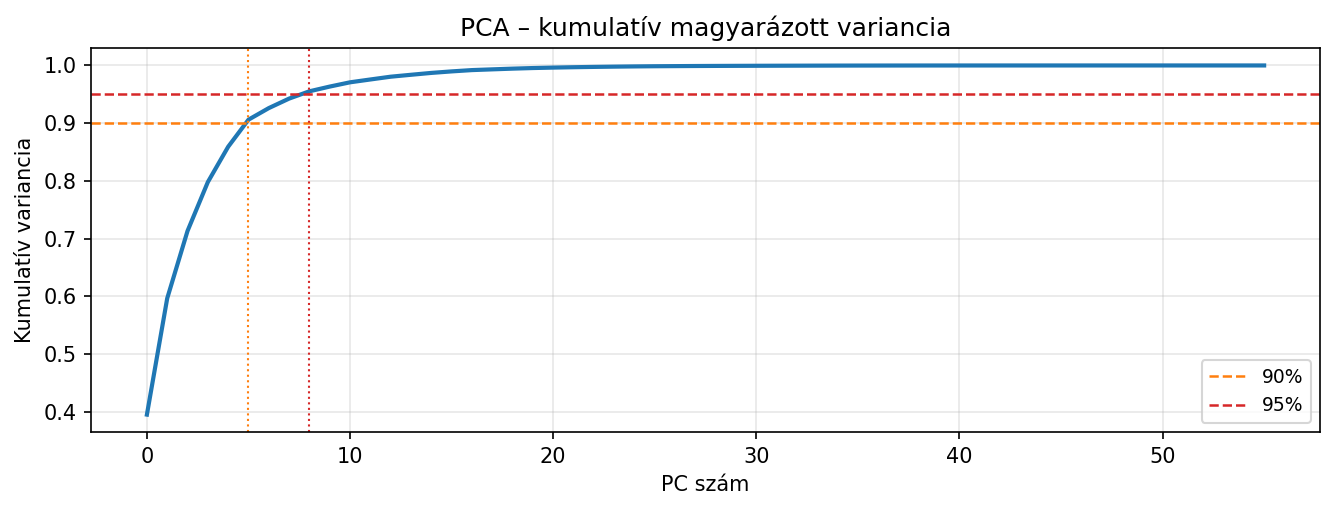

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tv)

pca_full = PCA(random_state=CFG['random_seed'])
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Hány PC kell 90% / 95% varianciához?
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n95 = int(np.searchsorted(cumvar, 0.95)) + 1
print(f'PC-k száma 90% variancia eléréséhez: {n90}')
print(f'PC-k száma 95% variancia eléréséhez: {n95}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(cumvar, 'C0-', lw=2)
ax.axhline(0.90, color='C1', ls='--', lw=1.2, label='90%')
ax.axhline(0.95, color='C3', ls='--', lw=1.2, label='95%')
ax.axvline(n90 - 1, color='C1', ls=':', lw=1)
ax.axvline(n95 - 1, color='C3', ls=':', lw=1)
ax.set_xlabel('PC szám')
ax.set_ylabel('Kumulatív variancia')
ax.set_title('PCA – kumulatív magyarázott variancia')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'pca_variance.png', dpi=130)
plt.show()

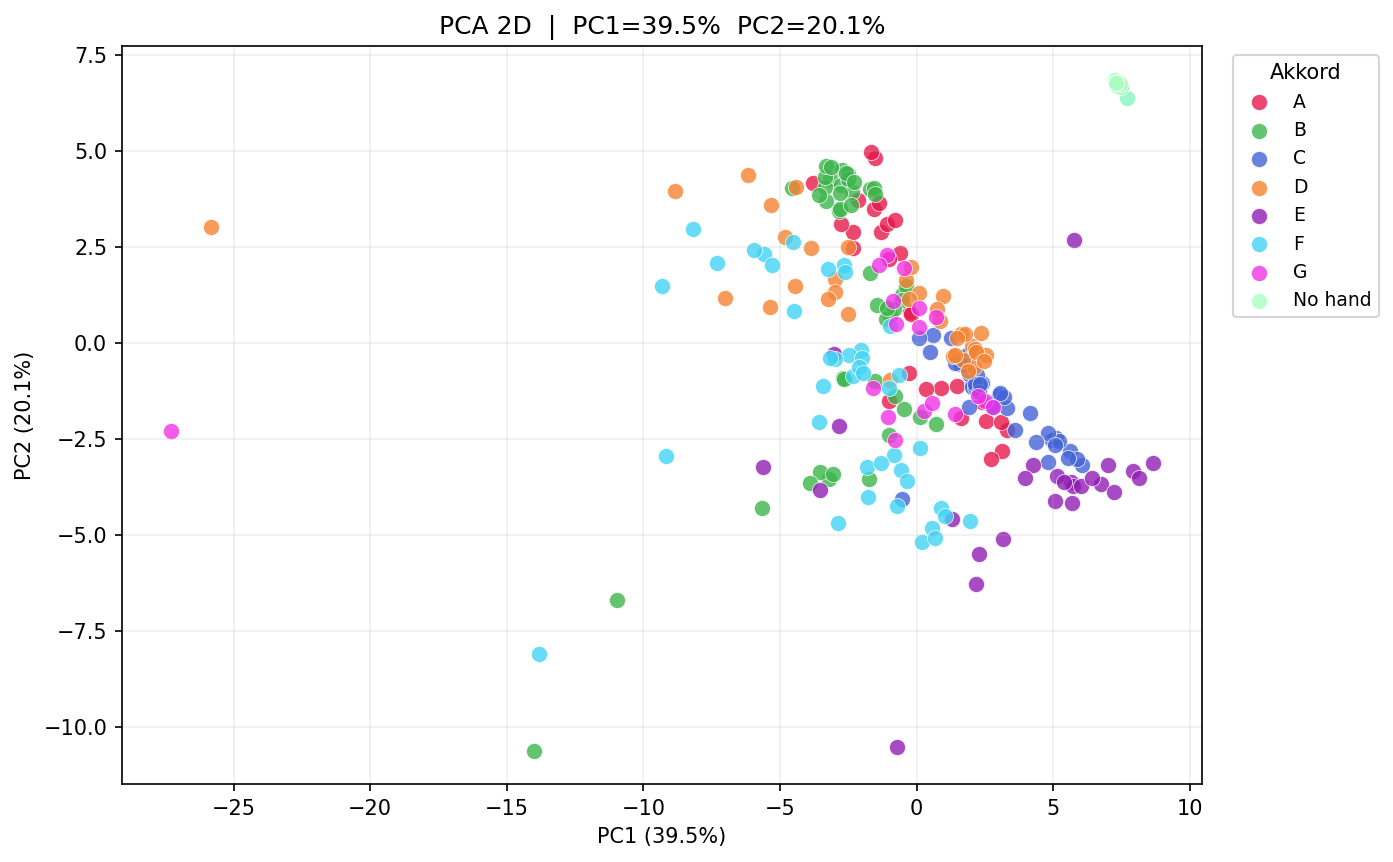

In [ ]:
# 2D PCA scatter
pca2 = PCA(n_components=2, random_state=CFG['random_seed'])
X_pca2 = pca2.fit_transform(X_scaled)

var1, var2 = pca2.explained_variance_ratio_
title_pca = (f'PCA 2D  |  PC1={var1*100:.1f}%  PC2={var2*100:.1f}%')

fig = plot_scatter_2d(
    X_pca2, y_tv, classes,
    title=title_pca,
    save_path=OUTPUT_DIR / 'pca_scatter.png',
)
plt.gca().set_xlabel(f'PC1 ({var1*100:.1f}%)')
plt.gca().set_ylabel(f'PC2 ({var2*100:.1f}%)')
plt.show()

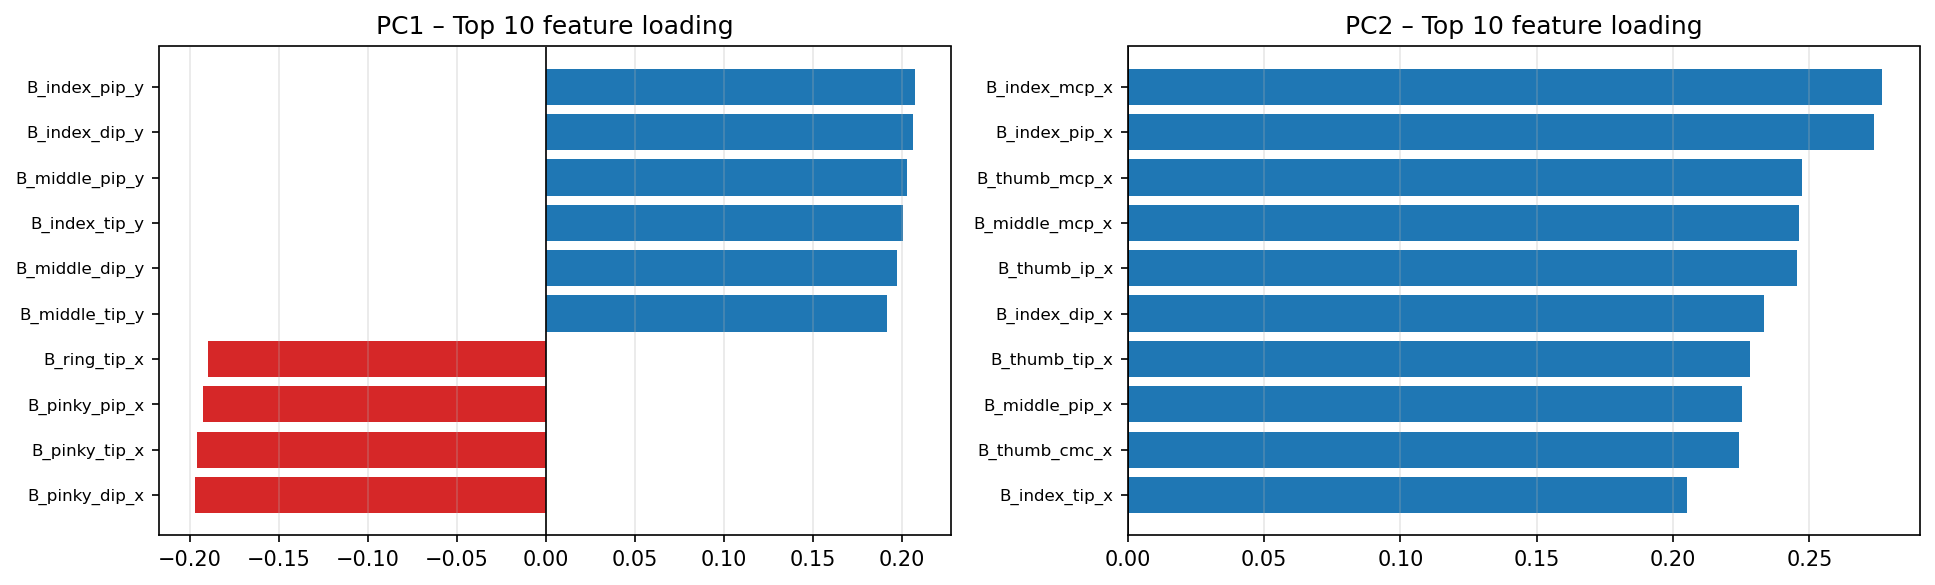

In [ ]:
# Első 2 PC legfontosabb feature-jei (loading plot)
loadings = pd.DataFrame(
    pca2.components_.T,
    index=fn,
    columns=['PC1', 'PC2']
)

# Top 10 legnagyobb abszolút értékű loading PC1-re
top_pc1 = loadings['PC1'].abs().nlargest(10).index
top_pc2 = loadings['PC2'].abs().nlargest(10).index

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, pc, top in [(axes[0], 'PC1', top_pc1), (axes[1], 'PC2', top_pc2)]:
    vals = loadings.loc[top, pc].sort_values()
    colors = ['C0' if v >= 0 else 'C3' for v in vals]
    ax.barh(range(len(vals)), vals.values, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=8)
    ax.set_title(f'{pc} – Top 10 feature loading')
    ax.axvline(0, color='black', lw=0.8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'pca_loadings.png', dpi=130)
plt.show()

## 5. t-SNE

t-SNE KL-divergencia: 0.3573


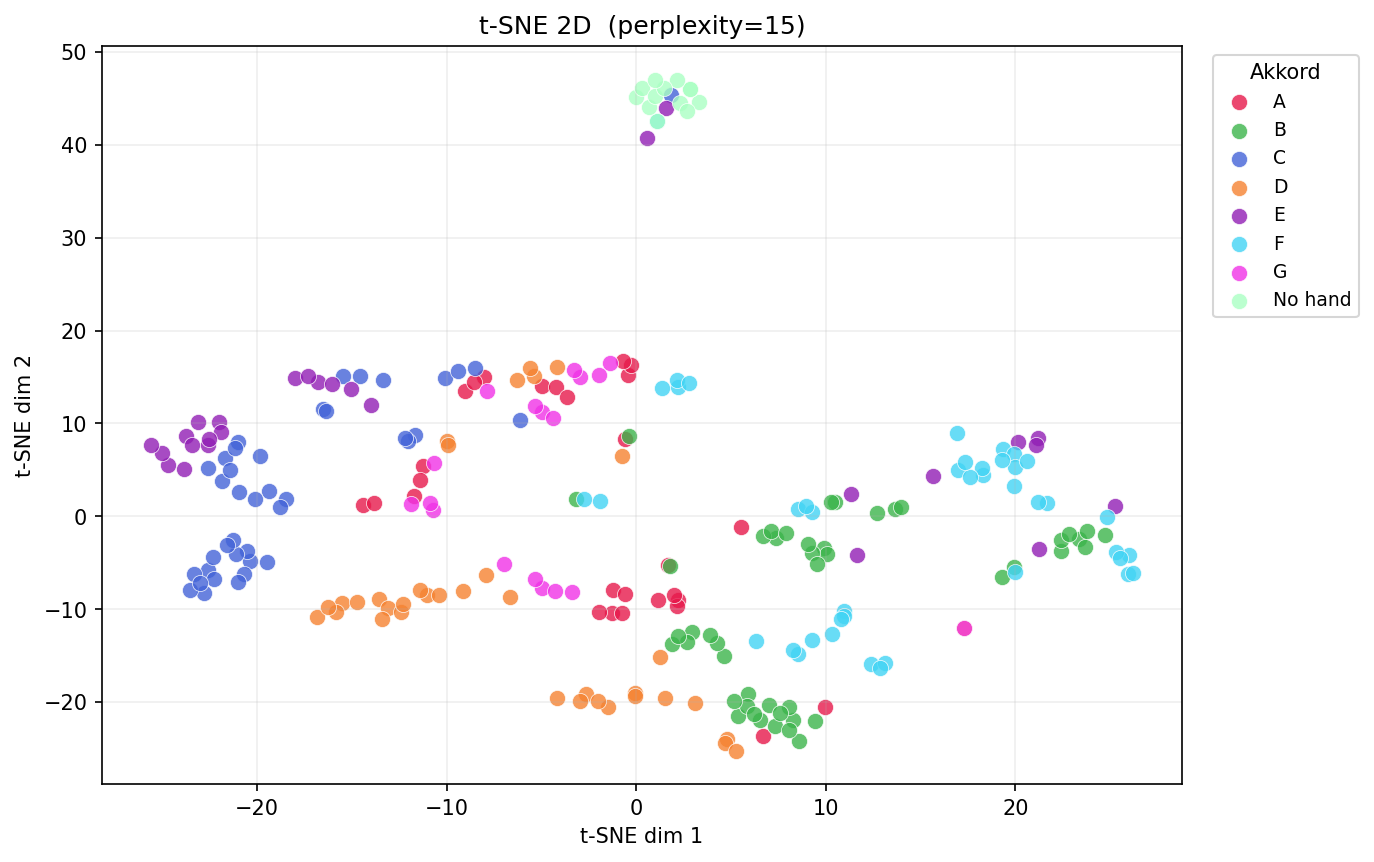

In [ ]:
# t-SNE (perplexity=15 a kis mintatér miatt)
tsne = TSNE(
    n_components=2,
    perplexity=15,
    learning_rate='auto',
    init='pca',
    random_state=CFG['random_seed'],
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X_scaled)

print(f't-SNE KL-divergencia: {tsne.kl_divergence_:.4f}')

fig = plot_scatter_2d(
    X_tsne, y_tv, classes,
    title='t-SNE 2D  (perplexity=15)',
    save_path=OUTPUT_DIR / 'tsne_scatter.png',
)
plt.gca().set_xlabel('t-SNE dim 1')
plt.gca().set_ylabel('t-SNE dim 2')
plt.show()

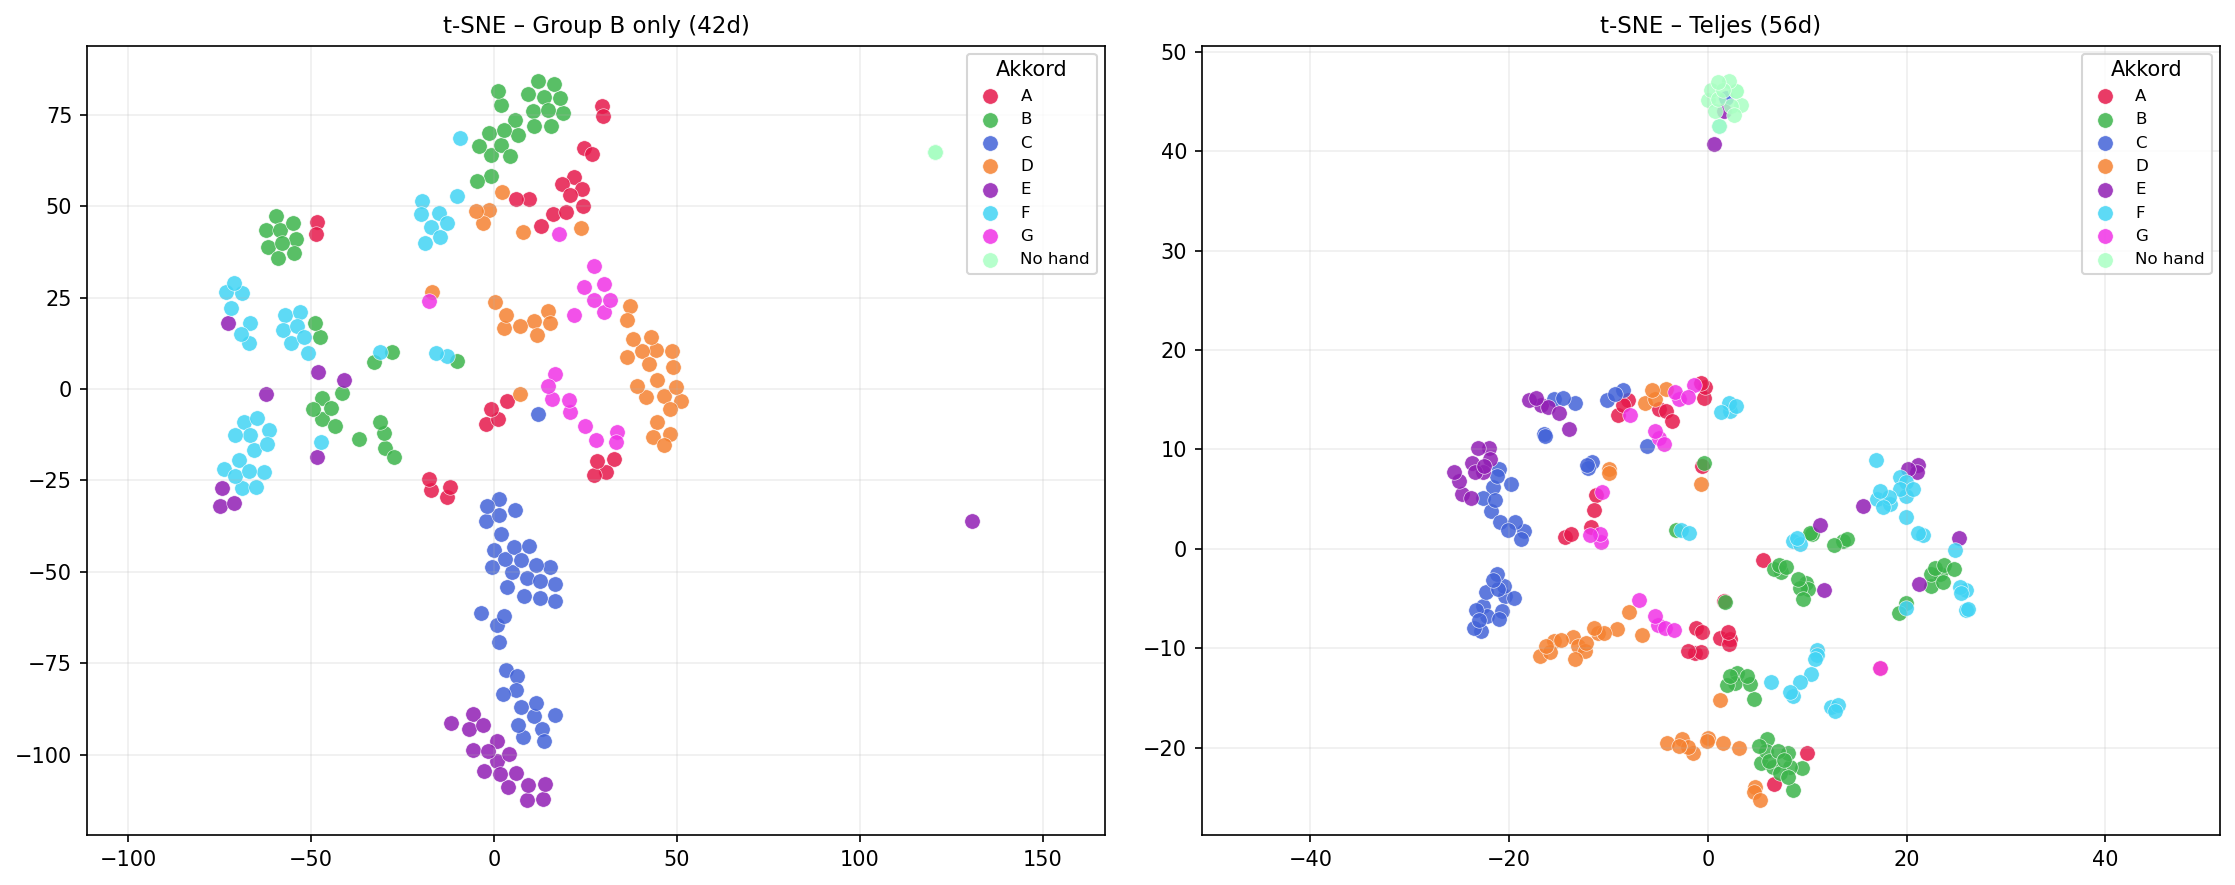

In [ ]:
# t-SNE Group B only vs. teljes 56-dim összehasonlítás
X_B_scaled = StandardScaler().fit_transform(X_tv[:, :42])
X_tsne_B = TSNE(
    n_components=2, perplexity=15,
    learning_rate='auto', init='pca',
    random_state=CFG['random_seed'], max_iter=1000,
).fit_transform(X_B_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, coords, ttl in [
    (axes[0], X_tsne_B, 't-SNE – Group B only (42d)'),
    (axes[1], X_tsne,   't-SNE – Teljes (56d)'),
]:
    for idx, cls_name in enumerate(classes):
        mask = y_tv == idx
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[class_color_mpl(idx)], label=cls_name,
                   s=55, alpha=0.85, edgecolors='white', linewidths=0.3)
    ax.set_title(ttl, fontsize=11)
    ax.legend(fontsize=8, title='Akkord')
    ax.grid(True, alpha=0.2)
    ax.axis('equal')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'tsne_B_vs_full.png', dpi=130)
plt.show()

## 6. Group ablation – csoportonkénti varianciaelemzés

Between-class variancia aránya (magasabb = jobb szeparáció):
Csoport  Between/(Total)
      B         0.414596
      H         0.343647
      D         0.262810
      G         0.194363
      F         0.111146


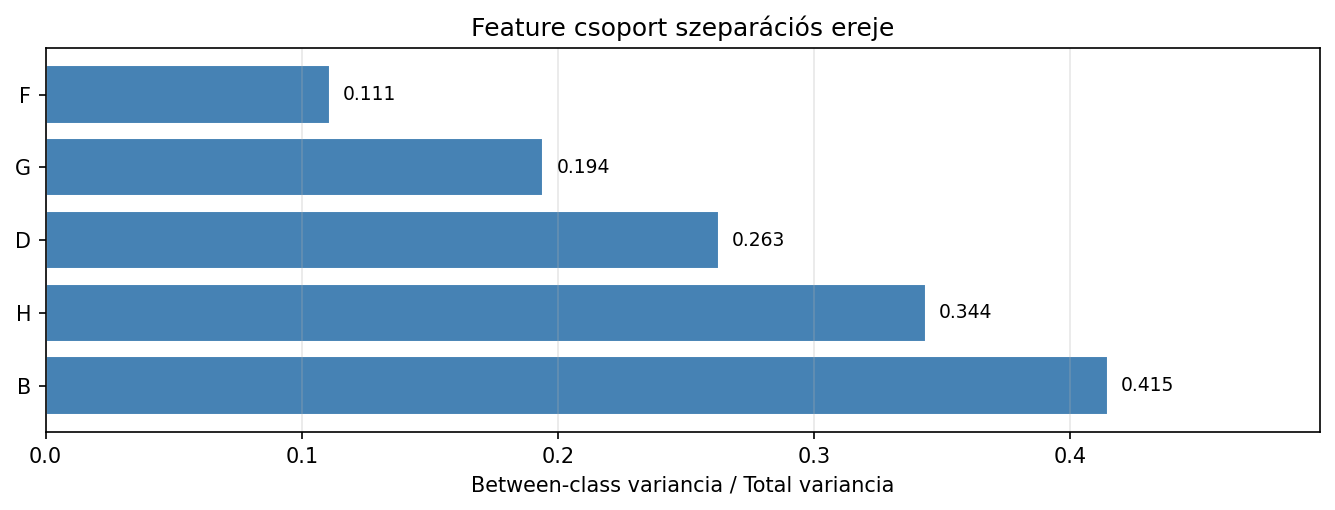

In [ ]:
# Between-class vs. within-class variancia minden csoportra
results = []
for g_name, g_sl in groups.items():
    subset = X_tv[:, g_sl]
    overall_mean = subset.mean(axis=0)
    
    # Within-class variancia
    within = 0.0
    between = 0.0
    for idx in range(len(classes)):
        cls_data = subset[y_tv == idx]
        if len(cls_data) == 0:
            continue
        cls_mean = cls_data.mean(axis=0)
        within += ((cls_data - cls_mean) ** 2).sum()
        between += len(cls_data) * ((cls_mean - overall_mean) ** 2).sum()
    
    total = within + between
    ratio = between / (total + 1e-12)
    results.append({'Csoport': g_name.split('–')[0].strip(), 'Between/(Total)': ratio,
                    'Between': between, 'Within': within})

df_ab = pd.DataFrame(results).sort_values('Between/(Total)', ascending=False)
print('Between-class variancia aránya (magasabb = jobb szeparáció):')
print(df_ab[['Csoport', 'Between/(Total)']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.barh(df_ab['Csoport'], df_ab['Between/(Total)'],
               color='steelblue', edgecolor='white')
for bar, v in zip(bars, df_ab['Between/(Total)']):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Between-class variancia / Total variancia')
ax.set_title('Feature csoport szeparációs ereje')
ax.set_xlim(0, df_ab['Between/(Total)'].max() * 1.2)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'group_ablation_variance.png', dpi=130)
plt.show()

## 7. Összefoglalás

In [ ]:
print('=== Feature Analízis Összefoglalás ===')
print(f'Feature dim: {X.shape[1]} (56 dim, B+D+F+G+H)')
print(f'Train+Val minta: {len(X_tv)}')
print(f'PCA – PC-k 90% varianciához: {n90}')
print(f'PCA – PC-k 95% varianciához: {n95}')
print()
print('Csoportok szeparációs ereje:')
print(df_ab[['Csoport', 'Between/(Total)']].to_string(index=False))
print()
print(f'Ábrák mentve: {OUTPUT_DIR}')
import os
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')

=== Feature Analízis Összefoglalás ===
Feature dim: 56 (56 dim, B+D+F+G+H)
Train+Val minta: 252
PCA – PC-k 90% varianciához: 6
PCA – PC-k 95% varianciához: 9

Csoportok szeparációs ereje:
Csoport  Between/(Total)
      B         0.414596
      H         0.343647
      D         0.262810
      G         0.194363
      F         0.111146

Ábrák mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/04_feature_analysis
  class_distribution.png
  correlation_group_B.png
  group_ablation_variance.png
  pca_loadings.png
  pca_scatter.png
  pca_variance.png
  tsne_B_vs_full.png
  tsne_scatter.png
